# Notebook 02: Hybrid MIL Patch Extraction
**Goal:** Extract patches from full mammograms and ROI crops using a hybrid 
strategy, then save patch arrays and a leak-free patient-level train/val split 
for downstream model training.

In [1]:
import sys
sys.path.append(
    '/kaggle/input/datasets/mfjmrizvi/cbis-ddsm-project-config'
)
import config as cfg
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import json
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf

print(f"TensorFlow: {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")
print(f"\nConfig loaded")
print(f"  PATCH_SIZE:  {cfg.PATCH_SIZE}")
print(f"  STRIDE:      {cfg.STRIDE}")
print(f"  MIN_STD:     {cfg.MIN_STD}")
print(f"  MAX_PATCHES: {cfg.MAX_PATCHES}")
print(f"  RANDOM_SEED: {cfg.RANDOM_SEED}")

NB01   = '/kaggle/input/notebooks/mfjmrizvi/01-dataset-setup-and-eda'
OUTPUT = '/kaggle/working'

Config loaded successfully


2026-06-26 14:04:52.275355: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782482692.472294      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782482692.526621      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782482692.969268      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782482692.969306      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782482692.969308      57 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

Config loaded
  PATCH_SIZE:  224
  STRIDE:      224
  MIN_STD:     15
  MAX_PATCHES: 20
  RANDOM_SEED: 42


## 1. Load Linked Metadata
Load the cleaned, path-linked CSVs produced by Notebook 01.

In [2]:
# Cell 2 — Load linked CSVs from Notebook 01

mass_train = pd.read_csv(f'{NB01}/mass_train_linked.csv')
mass_test  = pd.read_csv(f'{NB01}/mass_test_linked.csv')

print(f"mass_train: {mass_train.shape}")
print(f"mass_test:  {mass_test.shape}")
print(f"\nLabel distribution (train):")
print(mass_train['label'].value_counts())
print(f"\nFull image paths linked:    "
      f"{mass_train['full_image_path'].notna().sum()}")
print(f"Cropped image paths linked: "
      f"{mass_train['cropped_image_path'].notna().sum()}")

mass_train: (1318, 17)
mass_test:  (378, 17)

Label distribution (train):
label
0    681
1    637
Name: count, dtype: int64

Full image paths linked:    1318
Cropped image paths linked: 1318


## 2. Patient-Level Split Setup
Each row is one mammogram view, but one patient can have multiple views (LEFT_CC, LEFT_MLO etc). 
Splitting by row index would allow the same patient to appear in both 
train and validation. A data leakage risk. This maps rows to patient IDs 
first, then split at the patient level.

In [3]:
# Build mapping: row_index -> patient_id
bag_to_patient = dict(
    zip(mass_train.index, mass_train['patient_id'])
)

# Verify
unique_patients = mass_train['patient_id'].nunique()
unique_rows     = len(mass_train)
print(f"Unique patients in mass_train: {unique_patients}")
print(f"Total rows (views):            {unique_rows}")
print(f"Average views per patient:     "
      f"{unique_rows/unique_patients:.2f}")
print(f"\nSample mapping (first 5 rows):")
for idx, pid in list(bag_to_patient.items())[:5]:
    print(f"  row {idx} → {pid}")

Unique patients in mass_train: 691
Total rows (views):            1318
Average views per patient:     1.91

Sample mapping (first 5 rows):
  row 0 → P_00001
  row 1 → P_00001
  row 2 → P_00004
  row 3 → P_00004
  row 4 → P_00004


### 2b. Train / Validation Split
`GroupShuffleSplit` ensures no patient appears in both splits (train and validation sets). 
Zero overlap is a hard requirement and then verified below.

In [17]:
from sklearn.model_selection import GroupShuffleSplit

# We split the row indices of mass_train
# Groups = patient_id ensures patient-level split
row_indices = mass_train.index.values
patient_ids = mass_train['patient_id'].values

gss = GroupShuffleSplit(
    n_splits=1, test_size=0.2, random_state=cfg.RANDOM_SEED
)
train_rows, val_rows = next(
    gss.split(row_indices, groups=patient_ids)
)

# Convert to actual index values
train_bag_indices = row_indices[train_rows]
val_bag_indices   = row_indices[val_rows]

# Get corresponding patient ids for verification
train_patients = set(mass_train.loc[train_bag_indices, 'patient_id'])
val_patients   = set(mass_train.loc[val_bag_indices,   'patient_id'])

print(f"PATIENT-LEVEL TRAIN/VAL SPLIT")
print(f"Train bags (mammograms): {len(train_bag_indices)}")
print(f"Val bags (mammograms):   {len(val_bag_indices)}")
print(f"Train patients:          {len(train_patients)}")
print(f"Val patients:            {len(val_patients)}")
print(f"Patient overlap:         "
      f"{len(train_patients & val_patients)} "
      f"(must be 0)")

# Label distribution check
train_labels = mass_train.loc[train_bag_indices, 'label']
val_labels   = mass_train.loc[val_bag_indices,   'label']

print(f"\nTrain label distribution:")
print(train_labels.value_counts())
print(f"\nVal label distribution:")
print(val_labels.value_counts())

PATIENT-LEVEL TRAIN/VAL SPLIT
Train bags (mammograms): 1061
Val bags (mammograms):   257
Train patients:          552
Val patients:            139
Patient overlap:         0 (must be 0)

Train label distribution:
label
0    568
1    493
Name: count, dtype: int64

Val label distribution:
label
1    144
0    113
Name: count, dtype: int64


### 2c. Save Split Indices
Persisted as `.npy` files so downstream notebooks use the identical split 
without re-running this logic.

In [5]:
import json

# Save as numpy arrays
np.save(f'{OUTPUT}/train_bag_indices.npy', train_bag_indices)
np.save(f'{OUTPUT}/val_bag_indices.npy',   val_bag_indices)

# Save patient mapping as JSON for reference
bag_to_patient_serialisable = {
    str(k): v for k, v in bag_to_patient.items()
}
with open(f'{OUTPUT}/bag_to_patient_map.json', 'w') as f:
    json.dump(bag_to_patient_serialisable, f, indent=2)

print("Saved:")
print(f"  train_bag_indices.npy — {len(train_bag_indices)} bags")
print(f"  val_bag_indices.npy   — {len(val_bag_indices)} bags")
print(f"  bag_to_patient_map.json")

Saved:
  train_bag_indices.npy — 1061 bags
  val_bag_indices.npy   — 257 bags
  bag_to_patient_map.json


## 3. Patch Extraction Functions

Three functions implement the hybrid MIL strategy:

- `extract_patches_from_image`: grid scan over the full mammogram, filters 
  blank patches by standard deviation, then random spatial sampling
- `extract_patches_from_roi`: dense 50% overlap extraction from the 
  pre-cropped lesion region; resizes up if smaller than patch size
- `extract_hybrid_patches`: orchestrates both - malignant cases get ROI 
  patches + up to 5 context patches from the full image; benign cases use 
  full mammogram patches only

In [7]:
def extract_patches_from_image(image_path, patch_size, stride,
                                min_std, max_patches, seed=42):
    try:
        img = Image.open(image_path).convert('L')
        img_array = np.array(img, dtype=np.float32) / 255.0
        h, w = img_array.shape

        valid_patches   = []
        valid_positions = []

        for r in range(0, h - patch_size + 1, stride):
            for c in range(0, w - patch_size + 1, stride):
                patch = img_array[r:r+patch_size, c:c+patch_size]
                if patch.std() * 255 < min_std:
                    continue
                valid_patches.append(patch)
                valid_positions.append((r, c))

        total = len(valid_patches)
        if total == 0:
            return None, None, 0, 0

        if total > max_patches:
            rng = np.random.default_rng(seed)
            indices = sorted(
                rng.choice(total, max_patches, replace=False)
            )
            valid_patches   = [valid_patches[i]   for i in indices]
            valid_positions = [valid_positions[i] for i in indices]

        kept = len(valid_patches)
        patches_array = np.array(valid_patches)[..., np.newaxis]
        return patches_array, valid_positions, kept, total

    except Exception as e:
        print(f"Error (full): {image_path}: {e}")
        return None, None, 0, 0


def extract_patches_from_roi(cropped_path, patch_size,
                              min_std, seed=42):
    try:
        img = Image.open(cropped_path).convert('L')
        w, h = img.size

        # Resize up if smaller than patch_size
        if w < patch_size or h < patch_size:
            scale = max(patch_size / w, patch_size / h)
            new_w = max(int(w * scale), patch_size)
            new_h = max(int(h * scale), patch_size)
            img = img.resize((new_w, new_h), Image.LANCZOS)

        img_array = np.array(img, dtype=np.float32) / 255.0
        h, w = img_array.shape

        valid_patches   = []
        valid_positions = []
        roi_stride = patch_size // 2  # 50% overlap for ROI

        for r in range(0, h - patch_size + 1, roi_stride):
            for c in range(0, w - patch_size + 1, roi_stride):
                patch = img_array[r:r+patch_size, c:c+patch_size]
                if patch.std() * 255 < min_std:
                    continue
                valid_patches.append(patch)
                valid_positions.append((r, c))

        # Fallback: centre crop if no valid patches found
        if len(valid_patches) == 0:
            r_s = max(0, (h - patch_size) // 2)
            c_s = max(0, (w - patch_size) // 2)
            patch = img_array[r_s:r_s+patch_size, c_s:c_s+patch_size]
            if patch.shape == (patch_size, patch_size):
                valid_patches.append(patch)
                valid_positions.append((r_s, c_s))

        if len(valid_patches) == 0:
            return None, None, 0

        patches_array = np.array(valid_patches)[..., np.newaxis]
        return patches_array, valid_positions, len(valid_patches)

    except Exception as e:
        print(f"Error (ROI): {cropped_path}: {e}")
        return None, None, 0


def extract_hybrid_patches(row, patch_size, stride, min_std,
                            max_patches, seed=42):
    label = int(row['label'])

    if label == 1:  # MALIGNANT
        roi_patches, _, roi_kept = extract_patches_from_roi(
            row['cropped_image_path'], patch_size, min_std, seed
        )
        full_patches, _, full_kept, _ = extract_patches_from_image(
            row['full_image_path'], patch_size, stride,
            min_std, max_patches=5, seed=seed
        )

        parts = []
        if roi_patches is not None:
            parts.append(roi_patches)
        if full_patches is not None:
            parts.append(full_patches)

        if len(parts) == 0:
            return None, 0

        patches = np.concatenate(parts, axis=0)

        if len(patches) > max_patches:
            rng = np.random.default_rng(seed)
            idx = sorted(
                rng.choice(len(patches), max_patches, replace=False)
            )
            patches = patches[idx]

        return patches, len(patches)

    else:  # BENIGN
        patches, _, kept, _ = extract_patches_from_image(
            row['full_image_path'], patch_size, stride,
            min_std, max_patches, seed
        )
        return patches, kept if patches is not None else 0


print("Patch extraction functions defined:")
print("  extract_patches_from_image: full mammogram grid sampling")
print("  extract_patches_from_roi: ROI crop dense sampling")
print("  extract_hybrid_patches : hybrid MIL strategy")

Patch extraction functions defined:
  extract_patches_from_image: full mammogram grid sampling
  extract_patches_from_roi: ROI crop dense sampling
  extract_hybrid_patches : hybrid MIL strategy


## 4. Extraction Sanity Check
Test on one malignant and one benign image before running the full set.

In [10]:
print("SINGLE IMAGE EXTRACTION TEST")

for label_val, label_name in [(1, 'MALIGNANT'), (0, 'BENIGN')]:
    sample = mass_train[mass_train['label'] == label_val].iloc[0]
    patches, kept = extract_hybrid_patches(
        sample,
        cfg.PATCH_SIZE, cfg.STRIDE, cfg.MIN_STD, cfg.MAX_PATCHES
    )
    print(f"{label_name}:")
    print(f"  patient_id:     {sample['patient_id']}")
    print(f"  patches kept:   {kept}")
    if patches is not None:
        print(f"  array shape:    {patches.shape}")
        print(f"  pixel range:    "
              f"{patches.min():.3f} - {patches.max():.3f}")
        print(f"  mean pixel val: {patches.mean():.3f}")
    print()

SINGLE IMAGE EXTRACTION TEST
MALIGNANT:
  patient_id:     P_00001
  patches kept:   11
  array shape:    (11, 224, 224, 1)
  pixel range:    0.000 - 1.000
  mean pixel val: 0.380

BENIGN:
  patient_id:     P_00004
  patches kept:   20
  array shape:    (20, 224, 224, 1)
  pixel range:    0.000 - 1.000
  mean pixel val: 0.227



## 5. Visual Verification
Confirm the hybrid strategy produces visually meaningful patches. 
ROI coverage for malignant, spatial spread for benign.

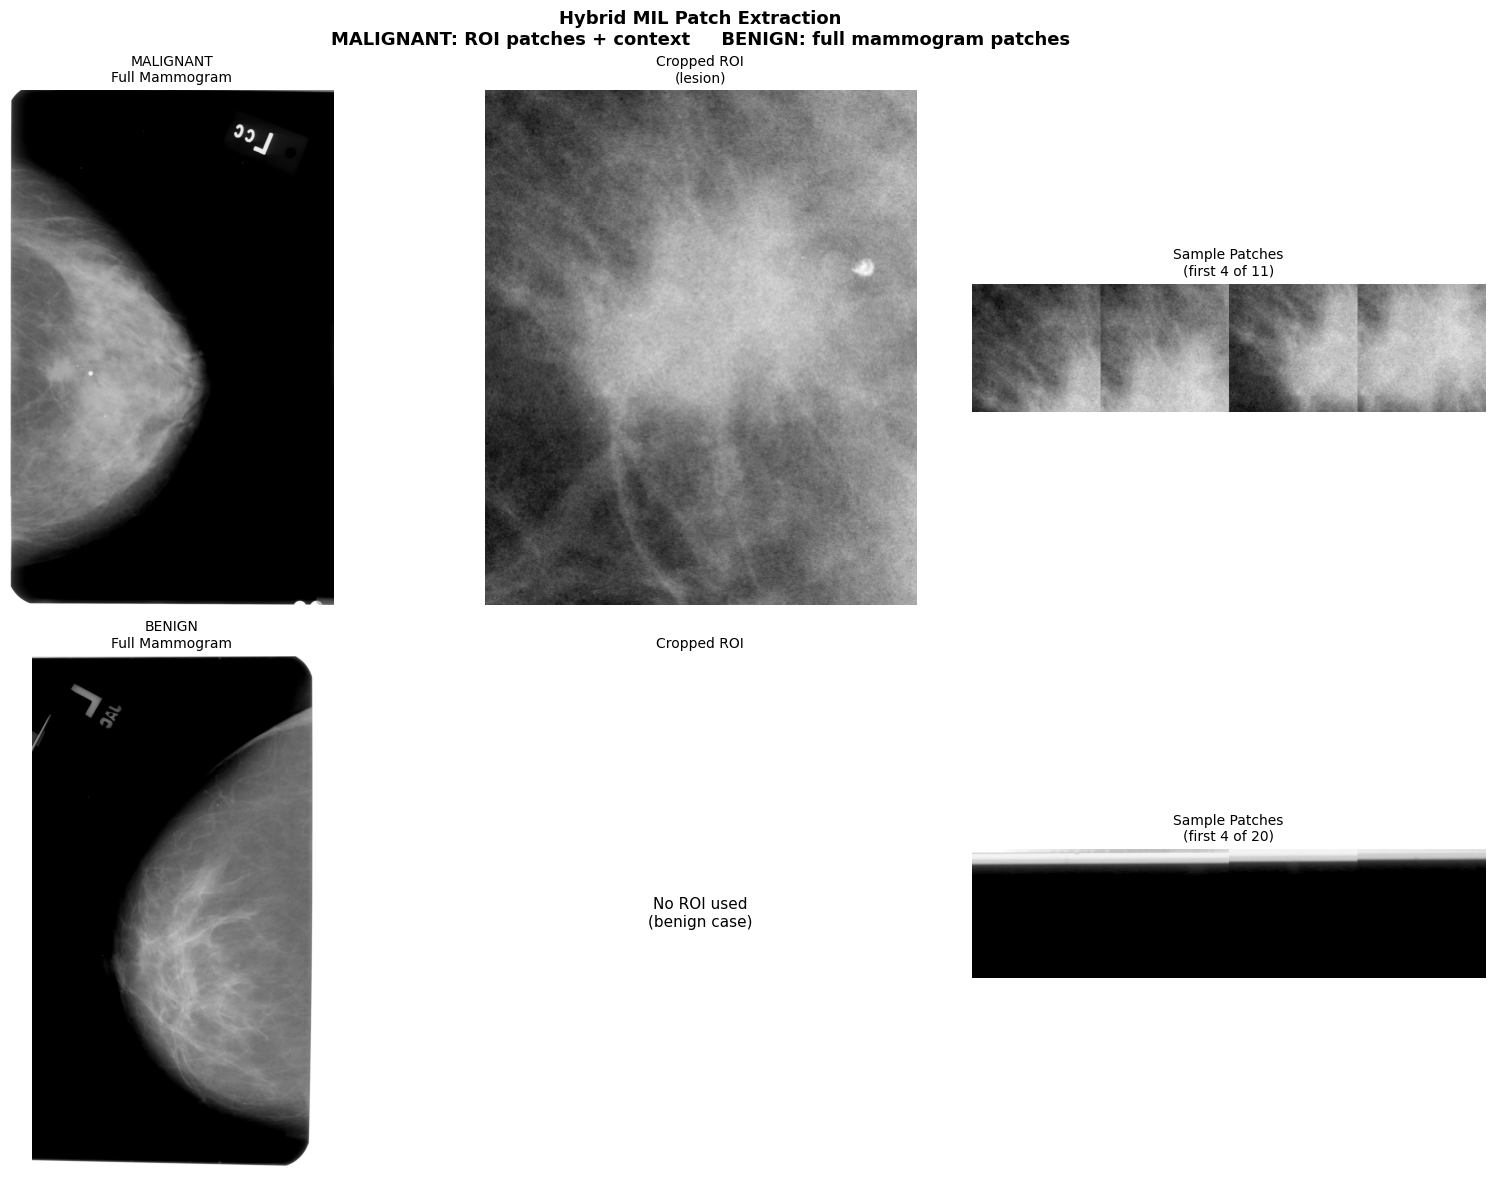

Visualisation saved


In [12]:
malignant_row = mass_train[mass_train['label'] == 1].iloc[0]
benign_row    = mass_train[mass_train['label'] == 0].iloc[0]

fig, axes = plt.subplots(2, 3, figsize=(16, 12))
fig.suptitle(
    'Hybrid MIL Patch Extraction\n'
    'MALIGNANT: ROI patches + context     BENIGN: full mammogram patches',
    fontsize=13, fontweight='bold'
)

for row_idx, (row, label_name) in enumerate(
        [(malignant_row, 'MALIGNANT'), (benign_row, 'BENIGN')]):

    patches, kept = extract_hybrid_patches(
        row, cfg.PATCH_SIZE, cfg.STRIDE,
        cfg.MIN_STD, cfg.MAX_PATCHES
    )

    # Column 0: full mammogram
    img_full = np.array(
        Image.open(row['full_image_path']).convert('L'))
    axes[row_idx, 0].imshow(img_full, cmap='gray')
    axes[row_idx, 0].set_title(
        f'{label_name}\nFull Mammogram', fontsize=10)
    axes[row_idx, 0].axis('off')

    # Column 1: cropped ROI (malignant) or blank (benign)
    if label_name == 'MALIGNANT':
        img_roi = np.array(
            Image.open(row['cropped_image_path']).convert('L'))
        axes[row_idx, 1].imshow(img_roi, cmap='gray')
        axes[row_idx, 1].set_title('Cropped ROI\n(lesion)', fontsize=10)
    else:
        axes[row_idx, 1].text(
            0.5, 0.5, 'No ROI used\n(benign case)',
            ha='center', va='center', fontsize=11,
            transform=axes[row_idx, 1].transAxes
        )
        axes[row_idx, 1].set_title('Cropped ROI', fontsize=10)
    axes[row_idx, 1].axis('off')

    # Column 2: patch grid
    if patches is not None and kept > 0:
        n_show = min(4, kept)
        grid = np.zeros((cfg.PATCH_SIZE, cfg.PATCH_SIZE * n_show))
        for i in range(n_show):
            grid[:, i*cfg.PATCH_SIZE:(i+1)*cfg.PATCH_SIZE] = \
                patches[i, :, :, 0]
        axes[row_idx, 2].imshow(grid, cmap='gray')
        axes[row_idx, 2].set_title(
            f'Sample Patches\n(first {n_show} of {kept})', fontsize=10)
    axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT}/hybrid_extraction_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Visualisation saved")

## 6. Patch Yield Statistics (50 Image Sample)
Profile patch counts before committing to the full extraction. 
Benign images consistently hit the `MAX_PATCHES=20` cap; malignant 
images average  roughly 9 patches due to smaller ROI sizes.

PATCH YIELD STATISTICS  (50 IMAGE SAMPLE)
Failed extractions: 0

Patches per image:
count    50.000000
mean     15.260000
std       6.063642
min       6.000000
25%       9.000000
50%      20.000000
75%      20.000000
max      20.000000
Name: kept, dtype: float64

By label:
       count       mean       std   min   25%   50%   75%   max
label                                                          
0       28.0  20.000000  0.000000  20.0  20.0  20.0  20.0  20.0
1       22.0   9.227273  4.208063   6.0   6.0   7.5  11.0  20.0


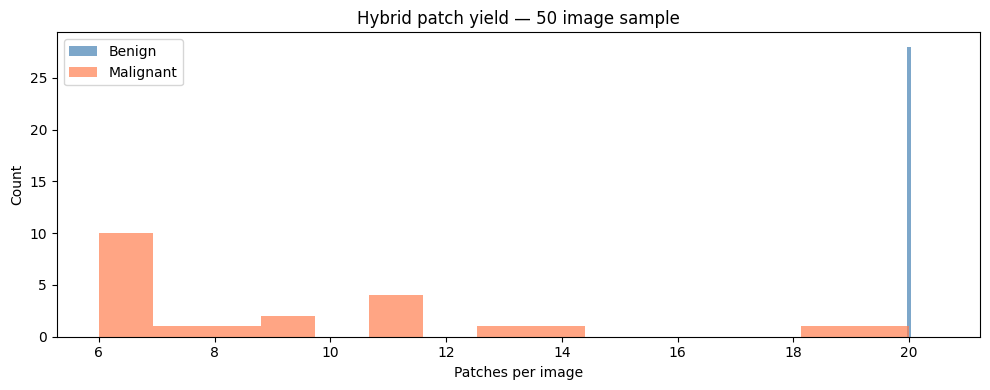

Plot saved


In [13]:
print("PATCH YIELD STATISTICS  (50 IMAGE SAMPLE)")
sample_df = mass_train.head(50)
stats = []

for _, row in sample_df.iterrows():
    patches, kept = extract_hybrid_patches(
        row, cfg.PATCH_SIZE, cfg.STRIDE,
        cfg.MIN_STD, cfg.MAX_PATCHES
    )
    stats.append({
        'label':  int(row['label']),
        'kept':   kept,
        'failed': patches is None
    })

stats_df = pd.DataFrame(stats)

print(f"Failed extractions: {stats_df['failed'].sum()}")
print(f"\nPatches per image:")
print(stats_df['kept'].describe())
print(f"\nBy label:")
print(stats_df.groupby('label')['kept'].describe())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(stats_df[stats_df['label']==0]['kept'],
        bins=15, alpha=0.7, label='Benign',    color='steelblue')
ax.hist(stats_df[stats_df['label']==1]['kept'],
        bins=15, alpha=0.7, label='Malignant', color='coral')
ax.set_xlabel('Patches per image')
ax.set_ylabel('Count')
ax.set_title('Hybrid patch yield — 50 image sample')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT}/hybrid_patch_stats.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

## 7. Full Patch Extraction: Training Set
Processes all 1,318 training images. 
**Takes several minutes**.  
Each image's seed is offset by its index for reproducible but 
varied sampling across rows.

In [14]:
# Progress printed every 200 images

print("FULL HYBRID EXTRACTION: TRAINING SET")
print(f"Images to process: {len(mass_train)}")
print(f"Parameters: patch_size={cfg.PATCH_SIZE}, "
      f"stride={cfg.STRIDE}, min_std={cfg.MIN_STD}, "
      f"max_patches={cfg.MAX_PATCHES}\n")

all_patches   = []
all_labels    = []
all_bag_ids   = []
failed_images = []

for idx, row in mass_train.iterrows():
    patches, kept = extract_hybrid_patches(
        row,
        cfg.PATCH_SIZE, cfg.STRIDE,
        cfg.MIN_STD, cfg.MAX_PATCHES,
        seed=cfg.RANDOM_SEED + idx
    )

    if patches is None or kept == 0:
        failed_images.append(row['patient_id'])
        continue

    all_patches.append(patches)
    all_labels.extend([int(row['label'])] * kept)
    all_bag_ids.extend([idx] * kept)

    if idx % 200 == 0:
        so_far = sum(len(p) for p in all_patches)
        print(f"  {idx}/{len(mass_train)} | "
              f"patches so far: {so_far}")

X_train       = np.concatenate(all_patches, axis=0)
y_train       = np.array(all_labels)
bag_ids_train = np.array(all_bag_ids)

print(f"\n=== TRAINING EXTRACTION COMPLETE ===")
print(f"X_train shape:        {X_train.shape}")
print(f"y_train distribution: {np.bincount(y_train)}")
print(f"Failed images:        {len(failed_images)}")
print(f"Memory:               {X_train.nbytes / 1024**3:.2f} GB")

FULL HYBRID EXTRACTION: TRAINING SET
Images to process: 1318
Parameters: patch_size=224, stride=224, min_std=15, max_patches=20

  0/1318 | patches so far: 11
  200/1318 | patches so far: 2972
  400/1318 | patches so far: 6120
  600/1318 | patches so far: 9147
  800/1318 | patches so far: 11897
  1000/1318 | patches so far: 14991
  1200/1318 | patches so far: 17996

=== TRAINING EXTRACTION COMPLETE ===
X_train shape:        (19770, 224, 224, 1)
y_train distribution: [13616  6154]
Failed images:        0
Memory:               3.70 GB


## 8. Full Patch Extraction: Test Set
Same extraction logic applied to the 378 held-out test images.  
Test set is **never used** for any split or weight computation.

In [15]:
print("FULL HYBRID EXTRACTION: TEST SET")
print(f"Images to process: {len(mass_test)}\n")

test_patches  = []
test_labels   = []
test_bag_ids  = []

for idx, row in mass_test.iterrows():
    patches, kept = extract_hybrid_patches(
        row,
        cfg.PATCH_SIZE, cfg.STRIDE,
        cfg.MIN_STD, cfg.MAX_PATCHES,
        seed=cfg.RANDOM_SEED + idx
    )

    if patches is None or kept == 0:
        continue

    test_patches.append(patches)
    test_labels.extend([int(row['label'])] * kept)
    test_bag_ids.extend([idx] * kept)

X_test       = np.concatenate(test_patches, axis=0)
y_test       = np.array(test_labels)
bag_ids_test = np.array(test_bag_ids)

print(f"X_test shape:        {X_test.shape}")
print(f"y_test distribution: {np.bincount(y_test)}")
print(f"Memory:              {X_test.nbytes / 1024**2:.1f} MB")

FULL HYBRID EXTRACTION: TEST SET
Images to process: 378

X_test shape:        (5997, 224, 224, 1)
y_test distribution: [4620 1377]
Memory:              1147.9 MB


## 9. Patch-Level Class Weight Computation
The hybrid strategy produces 2.2:1 benign:malignant patch imbalance 
(fewer malignant patches because ROI crops are smaller than full mammograms).  
Balanced class weights compensate for this during training.

In [18]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {
    0: float(class_weights_array[0]),
    1: float(class_weights_array[1])
}

print(f"PATCH-LEVEL CLASS WEIGHTS")
print(f"Benign patches:    {np.sum(y_train == 0)}")
print(f"Malignant patches: {np.sum(y_train == 1)}")
print(f"Raw ratio:         "
      f"{np.sum(y_train==0)/np.sum(y_train==1):.2f}:1")
print(f"\nClass weights:")
print(f"  Class 0 (benign):    {class_weight_dict[0]:.4f}")
print(f"  Class 1 (malignant): {class_weight_dict[1]:.4f}")
print(f"\nInterpretation: during training, each malignant patch")
print(f"contributes {class_weight_dict[1]/class_weight_dict[0]:.1f}x "
      f"more to the loss than each benign patch")

PATCH-LEVEL CLASS WEIGHTS
Benign patches:    13616
Malignant patches: 6154
Raw ratio:         2.21:1

Class weights:
  Class 0 (benign):    0.7260
  Class 1 (malignant): 1.6063

Interpretation: during training, each malignant patch
contributes 2.2x more to the loss than each benign patch


### 9b. Save Class Weights
Persisted as JSON so all three backbone training notebooks use 
identical weights without recomputing.

In [19]:
with open(f'{OUTPUT}/class_weights.json', 'w') as f:
    json.dump(class_weight_dict, f, indent=2)

print("Saved: class_weights.json")
print(json.dumps(class_weight_dict, indent=2))

Saved: class_weights.json
{
  "0": 0.7259841363102233,
  "1": 1.6062723431914203
}


## 10. Save All Outputs
Export patch arrays, bag IDs, split indices, and a metadata JSON 
documenting all extraction parameters and known limitations.

In [20]:
print("SAVING OUTPUTS")

np.save(f'{OUTPUT}/X_train_patches.npy', X_train)
np.save(f'{OUTPUT}/y_train_labels.npy',  y_train)
np.save(f'{OUTPUT}/bag_ids_train.npy',   bag_ids_train)
np.save(f'{OUTPUT}/X_test_patches.npy',  X_test)
np.save(f'{OUTPUT}/y_test_labels.npy',   y_test)
np.save(f'{OUTPUT}/bag_ids_test.npy',    bag_ids_test)

metadata = {
    'patch_size':          cfg.PATCH_SIZE,
    'stride':              cfg.STRIDE,
    'min_std':             cfg.MIN_STD,
    'max_patches':         cfg.MAX_PATCHES,
    'random_seed':         cfg.RANDOM_SEED,
    'strategy':            'hybrid_mil',
    'malignant_source':    'ROI crop patches + up to 5 context patches',
    'benign_source':       'random grid patches from full mammogram',
    'X_train_shape':       list(X_train.shape),
    'X_test_shape':        list(X_test.shape),
    'train_label_counts':  np.bincount(y_train).tolist(),
    'test_label_counts':   np.bincount(y_test).tolist(),
    'failed_train_images': len(failed_images),
    'split': {
        'train_bags':     len(train_bag_indices),
        'val_bags':       len(val_bag_indices),
        'split_level':    'patient_id',
        'patient_overlap': 0,
    },
    'class_weights': class_weight_dict,
    'preprocessing_notes': {
        'normalisation':     'divide by 255 inside extraction',
        'patch_size':        '224x224 matches EfficientNet-B0 input',
        'annotation_artefacts': (
            'MIN_STD=15 filters blank patches. '
            'Text annotations (CC MLO markers) not explicitly removed. '
            'Noted as limitation in report.'
        ),
        'validation_split': (
            'Patient-level GroupShuffleSplit 80/20. '
            'No patient appears in both train and val.'
        ),
        'label_noise': (
            'BENIGN_WITHOUT_CALLBACK merged with BENIGN. '
            'Residual label noise inherent to CBIS-DDSM. '
            'Noted as limitation in report.'
        )
    }
}

with open(f'{OUTPUT}/patch_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Updated metadata saved")
print(json.dumps(metadata, indent=2))

SAVING OUTPUTS
Updated metadata saved
{
  "patch_size": 224,
  "stride": 224,
  "min_std": 15,
  "max_patches": 20,
  "random_seed": 42,
  "strategy": "hybrid_mil",
  "malignant_source": "ROI crop patches + up to 5 context patches",
  "benign_source": "random grid patches from full mammogram",
  "X_train_shape": [
    19770,
    224,
    224,
    1
  ],
  "X_test_shape": [
    5997,
    224,
    224,
    1
  ],
  "train_label_counts": [
    13616,
    6154
  ],
  "test_label_counts": [
    4620,
    1377
  ],
  "failed_train_images": 0,
  "split": {
    "train_bags": 1061,
    "val_bags": 257,
    "split_level": "patient_id",
    "patient_overlap": 0
  },
  "class_weights": {
    "0": 0.7259841363102233,
    "1": 1.6062723431914203
  },
  "preprocessing_notes": {
    "normalisation": "divide by 255 inside extraction",
    "patch_size": "224x224 matches EfficientNet-B0 input",
    "annotation_artefacts": "MIN_STD=15 filters blank patches. Text annotations (CC MLO markers) not explicitly